# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [1]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats --quiet

Note: you may need to restart the kernel to use updated packages.


---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# YOUR CODE HERE:
def normalize_cwa_json(raw):
    """
    Detect JSON format and extract station list from different CWA data sources
    
    Args:
        raw (dict): Raw JSON response from CWA API or converted data
        
    Returns:
        list: Station list from the correct path, or None if not found
    """
    # Check for CWA API format: records.Station[]
    if 'records' in raw and isinstance(raw['records'], dict) and 'Station' in raw['records']:
        return raw['records']['Station']
    
    # Check for CWA XML download format: cwaopendata.dataset.Station[]
    elif 'cwaopendata' in raw and isinstance(raw['cwaopendata'], dict):
        dataset = raw['cwaopendata'].get('dataset', {})
        if 'Station' in dataset:
            return dataset['Station']
    
    # Station list not found
    return None


def parse_rainfall_json(data):
    """
    Parse rainfall JSON data into GeoDataFrame with proper coordinate handling
    
    Args:
        data (dict): JSON response from CWA API or converted data
        
    Returns:
        GeoDataFrame: Parsed rainfall data with CRS EPSG:4326
    """
    import geopandas as gpd
    import pandas as pd
    from shapely.geometry import Point
    import numpy as np
    
    # Get station list using normalize function
    stations = normalize_cwa_json(data)
    
    if stations is None:
        print("❌ No station data found in JSON")
        return gpd.GeoDataFrame()
    
    print(f"📊 Found {len(stations)} stations in data")
    
    # Parse each station
    parsed_stations = []
    
    for station in stations:
        try:
            # Handle coordinates - check both station level and GeoInfo level
            coords = station.get('Coordinates', [])
            geo_info = station.get('GeoInfo', {})
            
            # If no coordinates at station level, check GeoInfo
            if not coords and 'Coordinates' in geo_info:
                coords = geo_info['Coordinates']
            
            if len(coords) >= 2:
                # Find WGS84 coordinates
                wgs84_coord = None
                for coord in coords:
                    if coord.get('CoordinateName') == 'WGS84':
                        wgs84_coord = coord
                        break
                
                if wgs84_coord:
                    lon = float(wgs84_coord.get('StationLongitude', 0))
                    lat = float(wgs84_coord.get('StationLatitude', 0))
                else:
                    # Fallback to first coordinate if WGS84 not found
                    lon = float(coords[0].get('StationLongitude', 0))
                    lat = float(coords[0].get('StationLatitude', 0))
                    
            elif len(coords) == 1:
                # Use the single coordinate entry
                lon = float(coords[0].get('StationLongitude', 0))
                lat = float(coords[0].get('StationLatitude', 0))
            else:
                # No coordinates found, skip this station
                print(f"⚠️ No coordinates found for station {station.get('StationName', 'Unknown')}")
                continue
            
            # Extract rainfall data - handle both string and number types
            rainfall_element = station.get('RainfallElement', {})
            
            # Convert precipitation values to float, handling both str and number
            def safe_float_convert(value):
                if value is None or value == '' or value == -998:
                    return 0.0
                try:
                    return float(value)
                except (ValueError, TypeError):
                    return 0.0
            
            rain_1hr = safe_float_convert(rainfall_element.get('Past1hr', {}).get('Precipitation', 0))
            rain_3hr = safe_float_convert(rainfall_element.get('Past3hr', {}).get('Precipitation', 0))
            rain_24hr = safe_float_convert(rainfall_element.get('Past24hr', {}).get('Precipitation', 0))
            
            # Extract location info from GeoInfo
            county_name = geo_info.get('CountyName', '')
            town_name = geo_info.get('TownName', '')
            
            # Create parsed station record
            parsed_station = {
                'StationName': station.get('StationName', ''),
                'StationId': station.get('StationId', ''),
                'CountyName': county_name,
                'TownName': town_name,
                'rain_1hr': rain_1hr,
                'rain_3hr': rain_3hr,
                'rain_24hr': rain_24hr,
                'geometry': Point(lon, lat)
            }
            
            parsed_stations.append(parsed_station)
            
        except Exception as e:
            print(f"⚠️ Error parsing station {station.get('StationName', 'Unknown')}: {e}")
            continue
    
    if not parsed_stations:
        print("❌ No valid stations parsed")
        return gpd.GeoDataFrame()
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(parsed_stations, crs='EPSG:4326')
    
    # Filter out invalid coordinates (points at 0,0)
    valid_mask = (gdf.geometry.x != 0) & (gdf.geometry.y != 0)
    gdf = gdf[valid_mask]
    
    print(f"✅ Successfully parsed {len(gdf)} valid stations")
    print(f"📍 Coordinate range: Lon [{gdf.geometry.x.min():.3f}, {gdf.geometry.x.max():.3f}], Lat [{gdf.geometry.y.min():.3f}, {gdf.geometry.y.max():.3f}]")
    print(f"🌧️ Rainfall range: 1hr [0-{gdf.rain_1hr.max():.1f}], 3hr [0-{gdf.rain_3hr.max():.1f}], 24hr [0-{gdf.rain_24hr.max():.1f}] mm")
    
    return gdf

# 2. Load 'data/scenarios/fungwong_202511.json'
with open('data/scenario/fungwong_202511.json', 'r', encoding='utf-8') as f:
    rainfall_data = json.load(f)

# 3. Parse into GeoDataFrame
rainfall_gdf = parse_rainfall_json(rainfall_data)

# 4. Filter to 花蓮縣 + 宜蘭縣
study_counties = ['花蓮縣', '宜蘭縣']
study_rain = rainfall_gdf[rainfall_gdf['CountyName'].isin(study_counties)].copy()

print(f"\n📍 Stations in study area ({', '.join(study_counties)}): {len(study_rain)}")

# 5. Remove stations with rain_1hr <= 0 (including -998 which was converted to 0)
study_rain_filtered = study_rain[study_rain['rain_1hr'] > 0].copy()
print(f"📍 Stations with rain > 0: {len(study_rain_filtered)}")

# 6. Convert to EPSG:3826
study_rain_3826 = study_rain_filtered.to_crs('EPSG:3826')
print(f"📍 CRS: {study_rain_3826.crs}")

# Show top 5 stations by rain_1hr
print(f"\nTop 5 stations by 1hr rainfall:")
top5 = study_rain_3826.nlargest(5, 'rain_1hr')[['StationName', 'CountyName', 'rain_1hr']]
print(top5.to_string(index=False))

# Extract coordinate arrays for Kriging / ML
x = study_rain_3826.geometry.x.values  # Easting (meters)
y = study_rain_3826.geometry.y.values  # Northing (meters)
z = study_rain_3826['rain_1hr'].values

print(f"\nStudy area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print(f"Coordinate range: X [{x.min():.0f}, {x.max():.0f}], Y [{y.min():.0f}, {y.max():.0f}]")

📊 Found 1256 stations in data
✅ Successfully parsed 1256 valid stations
📍 Coordinate range: Lon [119.445, 122.080], Lat [21.901, 26.359]
🌧️ Rainfall range: 1hr [0-130.5], 3hr [0-217.0], 24hr [0-758.0] mm

📍 Stations in study area (花蓮縣, 宜蘭縣): 169
📍 Stations with rain > 0: 89
📍 CRS: EPSG:3826

Top 5 stations by 1hr rainfall:
StationName CountyName  rain_1hr
         蘇澳        宜蘭縣     130.5
    國五S047K        宜蘭縣      80.5
         五結        宜蘭縣      71.0
         冬山        宜蘭縣      61.5
    國五S041K        宜蘭縣      46.0

Study area stations (rain > 0): 89
CRS: EPSG:3826
Coordinate range: X [269261, 346034], Y [2563311, 2763948]


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

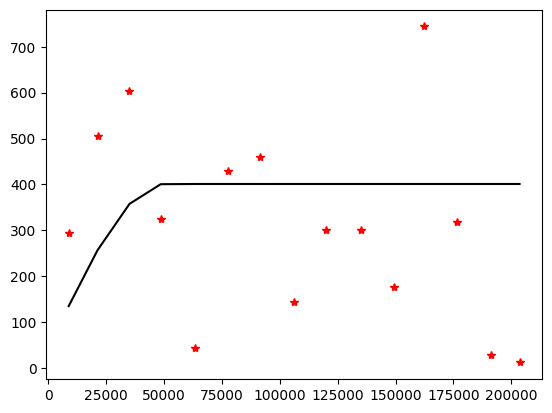

Sill:   360.8
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [3]:
from pykrige.ok import OrdinaryKriging

# 🔴 First attempt: run Kriging on raw rainfall data
# YOUR CODE HERE:
# 1. Create OrdinaryKriging with raw z values
#    Use variogram_model='spherical', verbose=False, enable_plotting=True, nlags=15
# 2. Provide initial parameters to help the optimizer:
#    sill = z.var(), range = 50000, nugget = z.var() * 0.1

initial_sill = float(z.var())
initial_range = 50000.0
initial_nugget = float(z.var() * 0.1)

OK_naive = OrdinaryKriging(x, y, z, variogram_model='spherical',
                          verbose=False, enable_plotting=True, nlags=15,
                          variogram_parameters={'sill': initial_sill,
                                                'range': initial_range,
                                                'nugget': initial_nugget})

params = OK_naive.variogram_model_parameters
print(f"Sill:   {params[0]:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")
print("\n⚠️ Look at the plot — do the dots follow the curve?")

## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

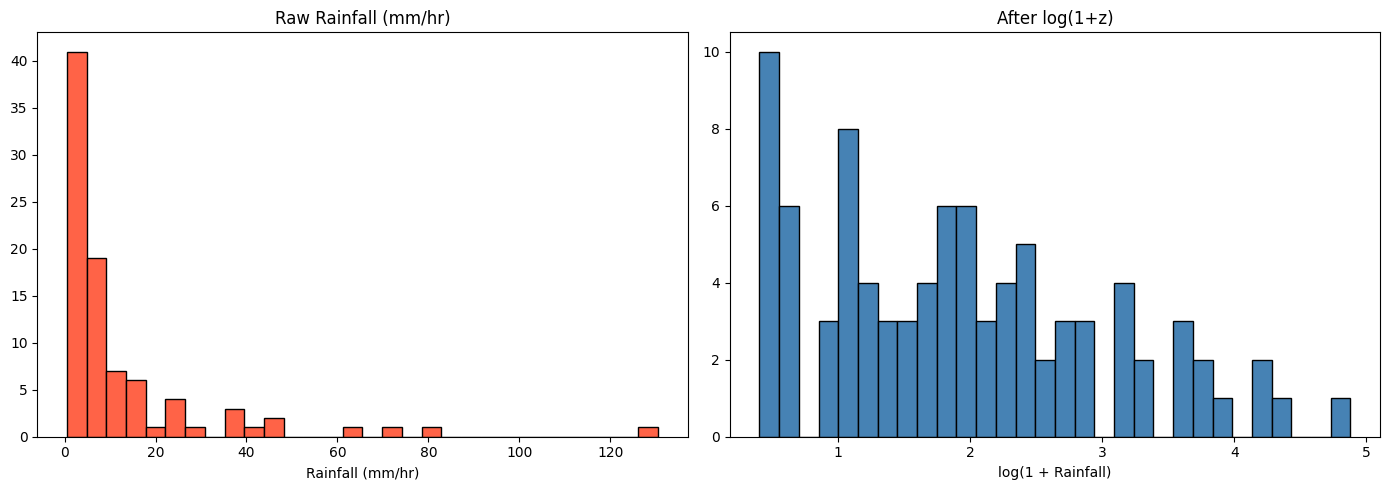

Left: most stations < 10 mm, but a few are 50-130 mm.
Those extreme values mess up the variogram.
Right: after log-transform, the values are more balanced.


In [4]:
# YOUR CODE HERE:
# 1. Plot a histogram of z (raw rainfall)
# 2. Plot a histogram of np.log1p(z) (log-transformed)
# 3. Compare: which one looks more "balanced"?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Raw Rainfall (mm/hr)')
axes[0].set_xlabel('Rainfall (mm/hr)')

z_log = np.log1p(z)
axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('After log(1+z)')
axes[1].set_xlabel('log(1 + Rainfall)')
plt.tight_layout()
plt.show()

print("Left: most stations < 10 mm, but a few are 50-130 mm.")
print("Those extreme values mess up the variogram.")
print("Right: after log-transform, the values are more balanced.")

## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

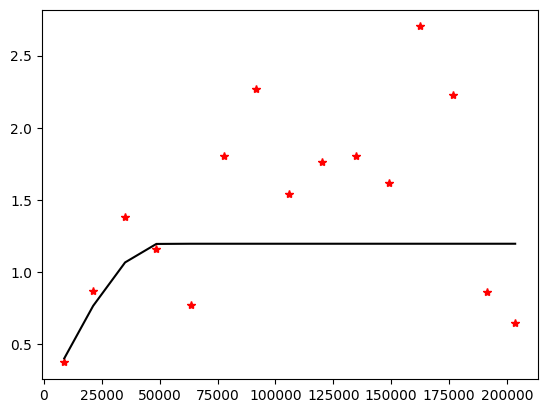

Sill:   1.076
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve now.


In [5]:
# 🟢 Second attempt: Kriging on log-transformed data
# YOUR CODE HERE:
# 1. z_log = np.log1p(z)  (already computed above)
# 2. Create OrdinaryKriging with z_log (not z!)
# 3. Use initial parameters based on z_log.var()

initial_sill = float(z_log.var())
initial_range = 50000.0
initial_nugget = float(z_log.var() * 0.1)

OK = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                      verbose=False, enable_plotting=True, nlags=15,
                      variogram_parameters={'sill': initial_sill,
                                            'range': initial_range,
                                         'nugget': initial_nugget})

params = OK.variogram_model_parameters
print(f"Sill:   {params[0]:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")
print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

Creating variogram models...
  spherical_50... ✓
  spherical_25... ✓
  spherical_15... ✓
  exponential_50... ✓
  exponential_25... ✓
  exponential_15... ✓


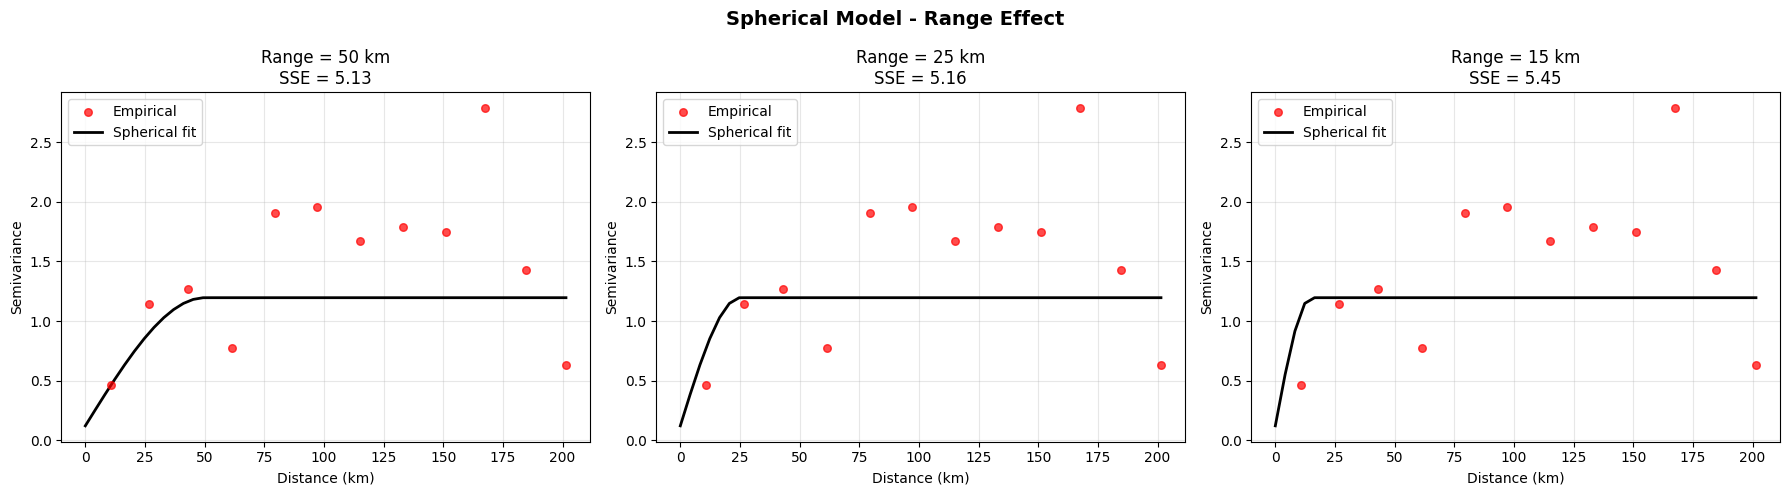

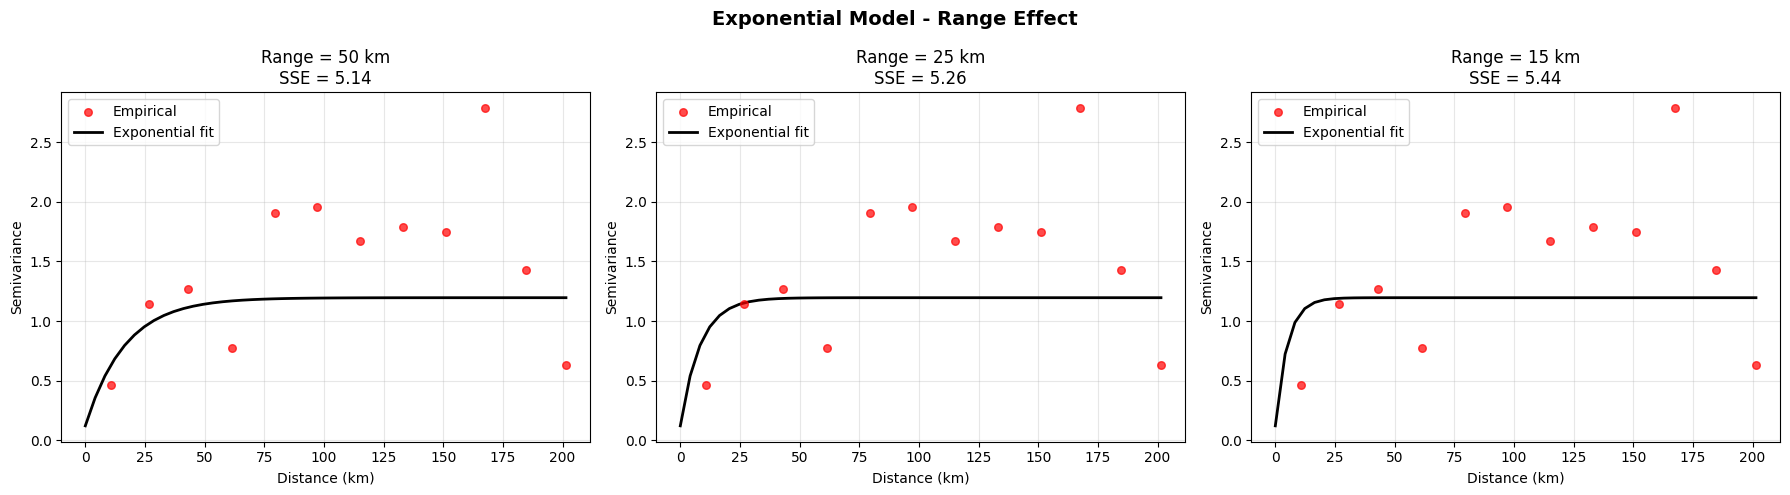


VARIOGRAM COMPARISON SUMMARY
      Model  Range_km  Sill  Range_m  Nugget   SSE
  Spherical        50 1.076    50000   0.120 5.127
  Spherical        25 1.076    25000   0.120 5.163
  Spherical        15 1.076    15000   0.120 5.449
Exponential        50 1.076    50000   0.120 5.135
Exponential        25 1.076    25000   0.120 5.256
Exponential        15 1.076    15000   0.120 5.435

──────────────────────────────────────────────────
ANALYSIS:
──────────────────────────────────────────────────

🔵 SPHERICAL MODEL (Range Effect):
  ★ Range 50 km: SSE = 5.13
    Range 25 km: SSE = 5.16
    Range 15 km: SSE = 5.45
  → Best range: 50 km (SSE = 5.13)

🟢 EXPONENTIAL MODEL (Range Effect):
  ★ Range 50 km: SSE = 5.14
    Range 25 km: SSE = 5.26
    Range 15 km: SSE = 5.44
  → Best range: 50 km (SSE = 5.14)

🔴 CROSS-MODEL COMPARISON (at each Range):
  Range 50 km: Spherical wins by 0.01 SSE
  Range 25 km: Spherical wins by 0.09 SSE
  Range 15 km: Exponential wins by 0.01 SSE

💡 QUESTIONS TO ANS

In [6]:
# YOUR CODE HERE:
# 1. Define ranges: [50000, 25000, 15000]
# 2. Figure 1: Spherical × 3 Ranges (1×3 subplot)
#    For each: create OrdinaryKriging, plot lags vs semivariance (red dots),
#    plot fitted curve (black line), compute SSE
# 3. Figure 2: Exponential × 3 Ranges (1×3 subplot)
#    Same as above but with variogram_model='exponential'
# 4. Print summary table:
#    - Compare within Spherical (Range effect)
#    - Compare within Exponential (Range effect)
#    - Compare Spherical vs Exponential at same Range (Model effect)

ranges_km = [50, 25, 15]
ranges_m = [r * 1000 for r in ranges_km]

# Compute z_log if not already computed
z_log = np.log1p(z)
sill_val = float(z_log.var())

# Define variogram functions manually
def spherical_variogram(h, sill, range_, nugget):
    """Spherical variogram model"""
    h = np.array(h)
    result = np.zeros_like(h)
    mask = h <= range_
    result[mask] = nugget + sill * (1.5 * h[mask] / range_ - 0.5 * (h[mask] / range_)**3)
    result[~mask] = nugget + sill
    return result

def exponential_variogram(h, sill, range_, nugget):
    """Exponential variogram model"""
    h = np.array(h)
    return nugget + sill * (1 - np.exp(-3 * h / range_))

def compute_sse(ok_model):
    """Compute Sum of Squared Errors for variogram fit"""
    # Empirical semivariance
    emp_semi = ok_model.semivariance
    # Model predictions at same lag distances
    if ok_model.variogram_model == 'spherical':
        model_semi = spherical_variogram(ok_model.lags, *ok_model.variogram_model_parameters)
    else:  # exponential
        model_semi = exponential_variogram(ok_model.lags, *ok_model.variogram_model_parameters)
    # SSE (ignore NaN values)
    valid_mask = ~np.isnan(emp_semi) & ~np.isnan(model_semi)
    return np.sum((emp_semi[valid_mask] - model_semi[valid_mask]) ** 2)

# Store results for summary table
results = []

# ─── Create all models first (faster batch processing) ───
print("Creating variogram models...")
models = {}
for model_type in ['spherical', 'exponential']:
    for rkm, rm in zip(ranges_km, ranges_m):
        key = f"{model_type}_{rkm}"
        print(f"  {key}...", end='')
        models[key] = OrdinaryKriging(x, y, z_log, variogram_model=model_type,
                                     verbose=False, enable_plotting=False, nlags=12,  # Reduced nlags
                                     variogram_parameters={'sill': sill_val,
                                                           'range': rm,
                                                           'nugget': sill_val * 0.1})
        print(" ✓")

# ─── Figure 1: Spherical ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Spherical Model - Range Effect', fontsize=14, fontweight='bold')

for ax, rkm in zip(axes, ranges_km):
    key = f"spherical_{rkm}"
    ok_test = models[key]
    
    # Plot empirical variogram (red dots)
    ax.scatter(ok_test.lags/1000, ok_test.semivariance, c='red', s=30, 
               alpha=0.7, label='Empirical', zorder=5)
    
    # Plot fitted model curve (black line) - using manual function
    lags_fine = np.linspace(0, max(ok_test.lags), 50)  # Reduced points
    model_curve = spherical_variogram(lags_fine, *ok_test.variogram_model_parameters)
    ax.plot(lags_fine/1000, model_curve, 'k-', linewidth=2, label='Spherical fit')
    
    # Compute SSE
    sse = compute_sse(ok_test)
    results.append({
        'Model': 'Spherical',
        'Range_km': rkm,
        'Sill': ok_test.variogram_model_parameters[0],
        'Range_m': ok_test.variogram_model_parameters[1],
        'Nugget': ok_test.variogram_model_parameters[2],
        'SSE': sse
    })
    
    # Formatting
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Semivariance')
    ax.set_title(f'Range = {rkm} km\nSSE = {sse:.2f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# ─── Figure 2: Exponential ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exponential Model - Range Effect', fontsize=14, fontweight='bold')

for ax, rkm in zip(axes, ranges_km):
    key = f"exponential_{rkm}"
    ok_test = models[key]
    
    # Plot empirical variogram (red dots)
    ax.scatter(ok_test.lags/1000, ok_test.semivariance, c='red', s=30, 
               alpha=0.7, label='Empirical', zorder=5)
    
    # Plot fitted model curve (black line) - using manual function
    lags_fine = np.linspace(0, max(ok_test.lags), 50)  # Reduced points
    model_curve = exponential_variogram(lags_fine, *ok_test.variogram_model_parameters)
    ax.plot(lags_fine/1000, model_curve, 'k-', linewidth=2, label='Exponential fit')
    
    # Compute SSE
    sse = compute_sse(ok_test)
    results.append({
        'Model': 'Exponential',
        'Range_km': rkm,
        'Sill': ok_test.variogram_model_parameters[0],
        'Range_m': ok_test.variogram_model_parameters[1],
        'Nugget': ok_test.variogram_model_parameters[2],
        'SSE': sse
    })
    
    # Formatting
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Semivariance')
    ax.set_title(f'Range = {rkm} km\nSSE = {sse:.2f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# ─── Summary Table ───
results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("VARIOGRAM COMPARISON SUMMARY")
print("="*80)
print(results_df.to_string(index=False, float_format='%.3f'))

print("\n" + "─"*50)
print("ANALYSIS:")
print("─"*50)

# Within Spherical comparison
sphere_results = results_df[results_df['Model'] == 'Spherical'].sort_values('SSE')
best_sphere = sphere_results.iloc[0]
print(f"\n🔵 SPHERICAL MODEL (Range Effect):")
for _, row in sphere_results.iterrows():
    marker = "★" if row['SSE'] == best_sphere['SSE'] else " "
    print(f"  {marker} Range {row['Range_km']} km: SSE = {row['SSE']:.2f}")
print(f"  → Best range: {best_sphere['Range_km']} km (SSE = {best_sphere['SSE']:.2f})")

# Within Exponential comparison
exp_results = results_df[results_df['Model'] == 'Exponential'].sort_values('SSE')
best_exp = exp_results.iloc[0]
print(f"\n🟢 EXPONENTIAL MODEL (Range Effect):")
for _, row in exp_results.iterrows():
    marker = "★" if row['SSE'] == best_exp['SSE'] else " "
    print(f"  {marker} Range {row['Range_km']} km: SSE = {row['SSE']:.2f}")
print(f"  → Best range: {best_exp['Range_km']} km (SSE = {best_exp['SSE']:.2f})")

# Cross-model comparison at same ranges
print(f"\n🔴 CROSS-MODEL COMPARISON (at each Range):")
for rkm in ranges_km:
    sphere_sse = results_df[(results_df['Model'] == 'Spherical') & 
                           (results_df['Range_km'] == rkm)]['SSE'].iloc[0]
    exp_sse = results_df[(results_df['Model'] == 'Exponential') & 
                        (results_df['Range_km'] == rkm)]['SSE'].iloc[0]
    winner = "Spherical" if sphere_sse < exp_sse else "Exponential"
    diff = abs(sphere_sse - exp_sse)
    print(f"  Range {rkm} km: {winner} wins by {diff:.2f} SSE")

print(f"\n💡 QUESTIONS TO ANSWER:")
print(f"  1. Within Spherical: Which Range gives the best fit?")
print(f"  2. Within Exponential: Which Range gives the best fit?") 
print(f"  3. At same Range: Does model choice matter much?")

## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [7]:
import time

# YOUR CODE HERE:
# 1. Calculate grid extent from x, y arrays (with 5km buffer)
# 2. Create grid_x and grid_y using np.arange with 1000m step
# 3. Execute Kriging in log-space: z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# 4. Back-transform: z_kriging = np.expm1(z_kriging_log)

buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# Back-transform to real rainfall (mm/hr)
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0
ss_kriging = ss_kriging_log  # keep log-space variance for Sigma Map

print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

Grid: 87×211 = 18,357 points @ 1000m
✓ Kriging (log-space) done in 0.1s
  z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

In [8]:
from sklearn.ensemble import RandomForestRegressor

# YOUR CODE HERE:
# 1. Prepare features: X_train = np.column_stack([x, y])
# 2. Train RandomForestRegressor
# 3. Create meshgrid from grid_x, grid_y
# 4. Predict on the grid

X_train = np.column_stack([x, y])
y_train = z

rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)
print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

RF Training R²: 0.775
✓ Random Forest done in 0.0s
  z range: 0.6 - 62.6 mm/hr


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [9]:
# YOUR CODE HERE:
# 1. Print rf.feature_importances_
# 2. Interpret: which dimension matters more for typhoon rainfall?

importances = rf.feature_importances_
print("Feature Importance:")
print(f"  Easting (X):  {importances[0]:.3f}")
print(f"  Northing (Y): {importances[1]:.3f}")
print(f"\nThe model relies mostly on {'easting' if importances[0] > importances[1] else 'northing'}.")
print("Think: does this make physical sense for Typhoon Fung-wong?")

Feature Importance:
  Easting (X):  0.485
  Northing (Y): 0.515

The model relies mostly on northing.
Think: does this make physical sense for Typhoon Fung-wong?


---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [10]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# YOUR CODE HERE:
# 1. Nearest Neighbor interpolation
# 2. IDW interpolation (手動實作，power=2)
#    ⚠️ 注意：不要用 Rbf(function='inverse')，它不是真正的 IDW，會產生極端值

nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
z_nn = nn_interp(grid_xx, grid_yy)

pts = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
dists = cdist(grid_pts, pts)
dists[dists < 1] = 1  # 避免除以零
power = 2
weights = 1.0 / (dists ** power)
z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

print("✓ Nearest Neighbor + IDW computed")

✓ Nearest Neighbor + IDW computed


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

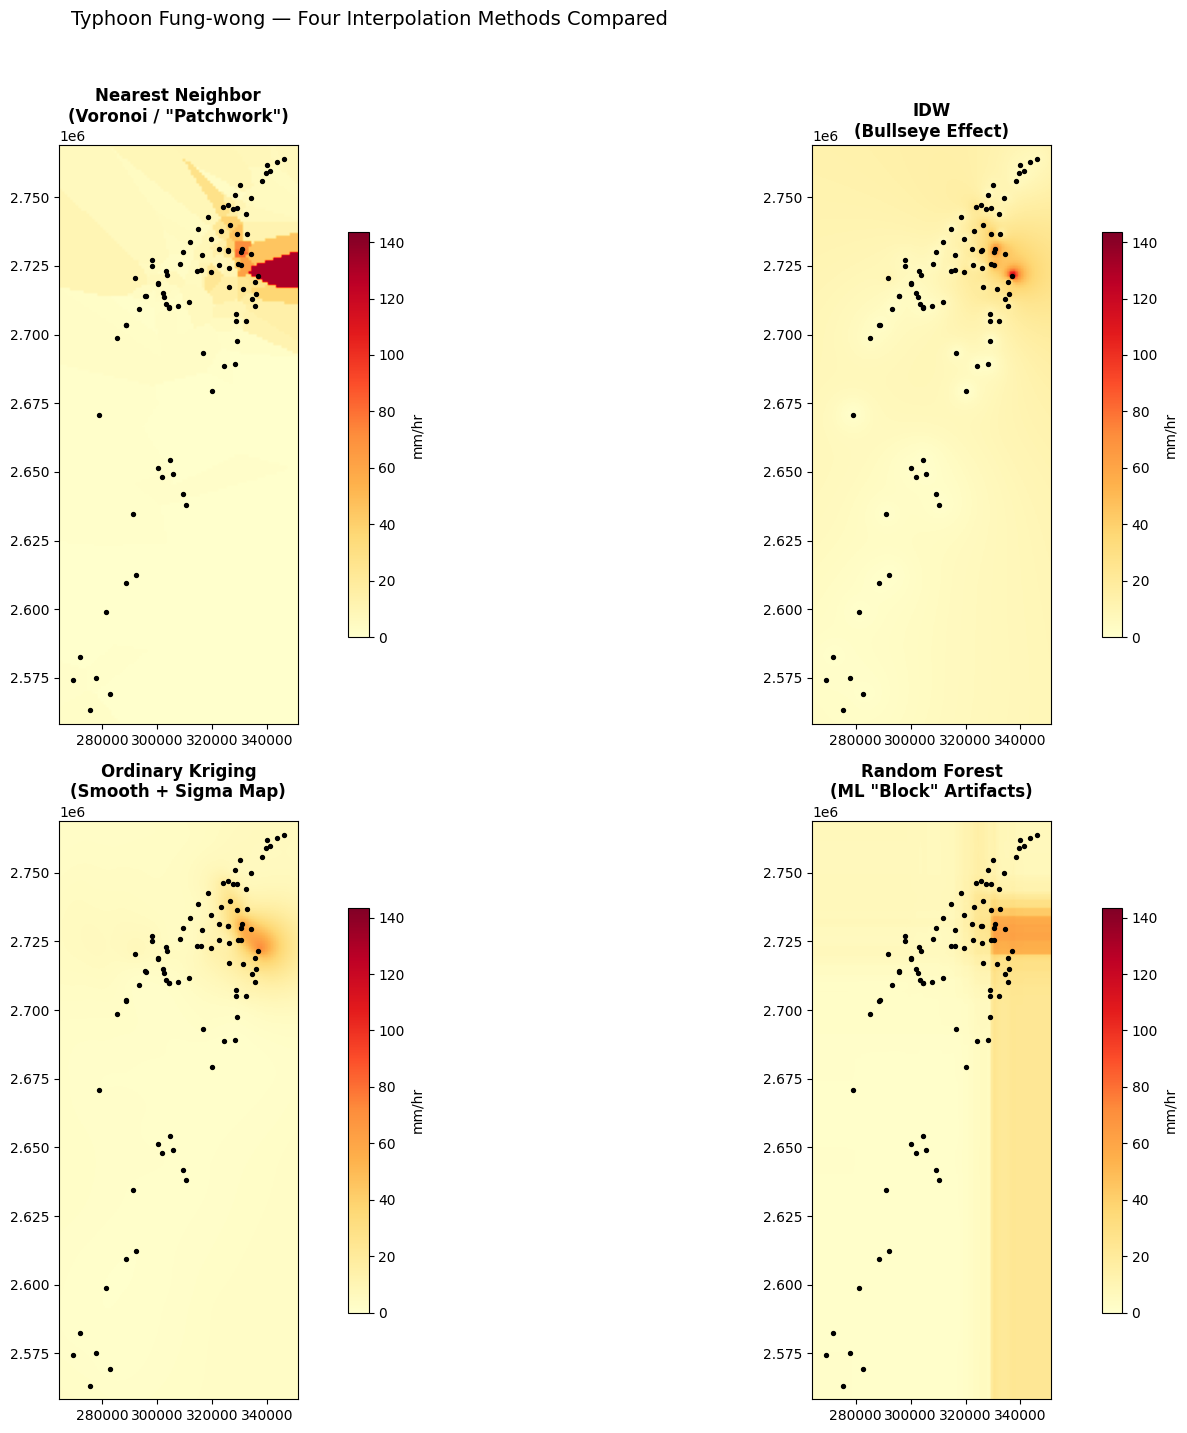

In [11]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(2, 2, figsize=(18, 14))
# 2. Plot all four methods with imshow
# 3. Use extent=[x_min, x_max, y_min, y_max], origin='lower'
# 4. Overlay station scatter points
# 5. Add colorbars, titles, save figure

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
vmax = max(z) * 1.1
methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)', z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf),
]

for ax, (title, data) in zip(axes.flatten(), methods):
    im = ax.imshow(data, extent=[x_min, x_max, y_min, y_max],
                   origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
    ax.scatter(x, y, c='black', s=8, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

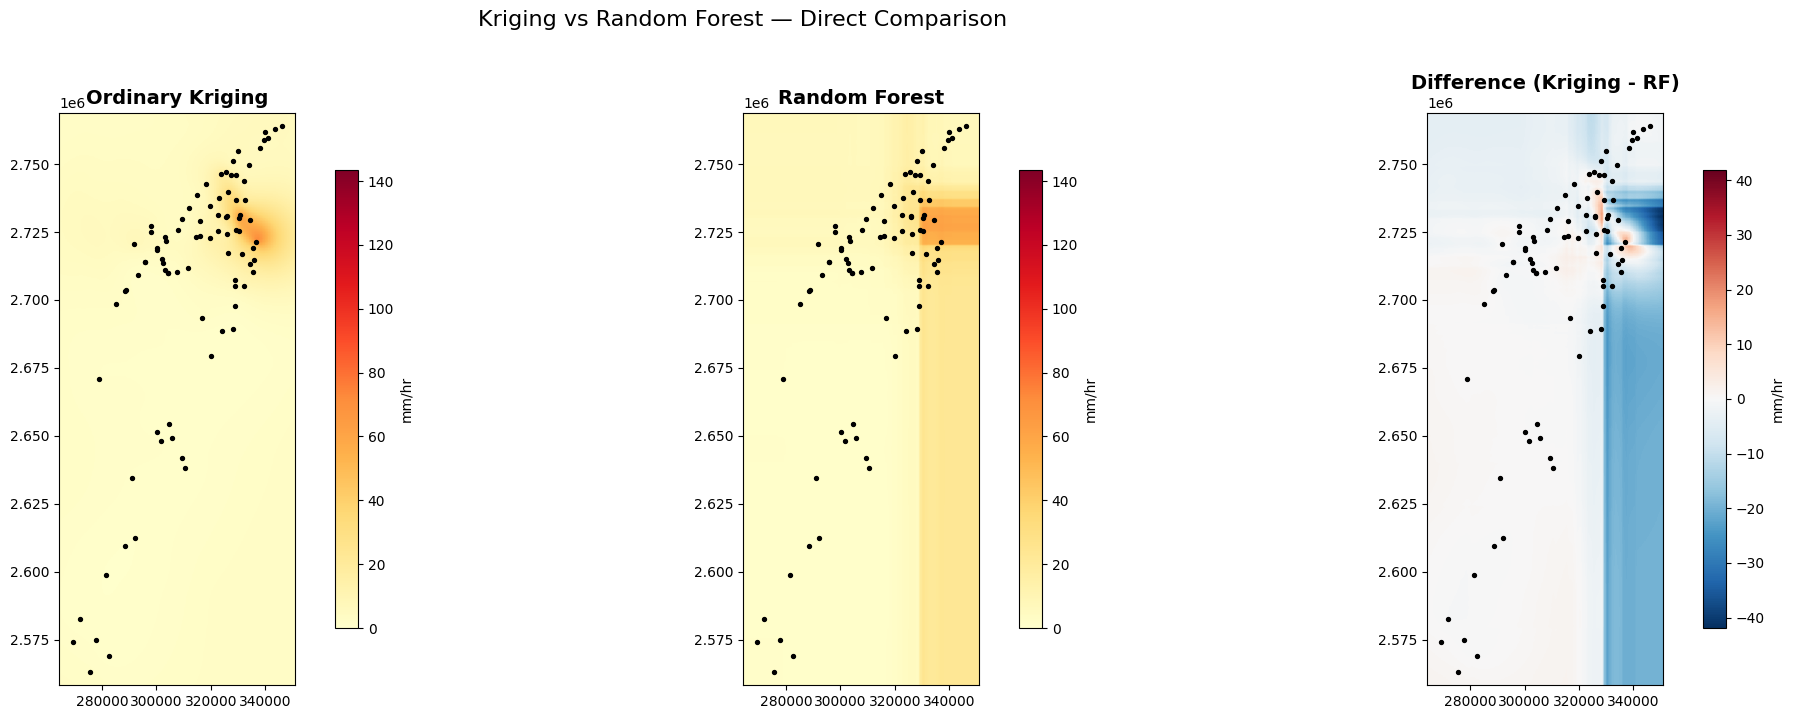

Difference range: -41.89 to 17.35 mm/hr
Red areas: Kriging > RF | Blue areas: RF > Kriging


In [12]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# 2. Left: Kriging (YlOrRd)
# 3. Middle: Random Forest (YlOrRd)
# 4. Right: Difference (Kriging - RF) using RdBu_r colormap
# 5. Save as 'kriging_vs_rf.png'

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Left: Kriging
im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
                     origin='lower', cmap='YlOrRd', vmin=0, vmax=max(z)*1.1)
axes[0].scatter(x, y, c='black', s=8, zorder=5)
axes[0].set_title('Ordinary Kriging', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Middle: Random Forest
im2 = axes[1].imshow(z_rf, extent=[x_min, x_max, y_min, y_max],
                     origin='lower', cmap='YlOrRd', vmin=0, vmax=max(z)*1.1)
axes[1].scatter(x, y, c='black', s=8, zorder=5)
axes[1].set_title('Random Forest', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

# Right: Difference Map
diff = z_kriging - z_rf
vmax_diff = max(abs(diff.min()), abs(diff.max()))
im3 = axes[2].imshow(diff, extent=[x_min, x_max, y_min, y_max],
                     origin='lower', cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
axes[2].scatter(x, y, c='black', s=8, zorder=5)
axes[2].set_title('Difference (Kriging - RF)', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[2], shrink=0.8, label='mm/hr')

plt.suptitle('Kriging vs Random Forest — Direct Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('kriging_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Difference range: {diff.min():.2f} to {diff.max():.2f} mm/hr")
print(f"Red areas: Kriging > RF | Blue areas: RF > Kriging")

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Your Lab 1 reflection here:**

1. Most realistic: 
    Kriging, as it has the gradiant feature, unlike the blocky prediction from random forest.

2. Disagreement areas: 
    Basically wherever the Random forest prediction starts adding values over 0. But you also see that near the places that has the most rainfall, they disagree the most. This means that whenever you need to choose between the two, you need to make sure what exactly do you want, accuracy? or fast?
3. Artifacts: 
    The North-South direction blocky feature that wouldn't exist in real world.
4. Commander's choice: 
    Kriging, as it is more realistic and has the gradiant feature.

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

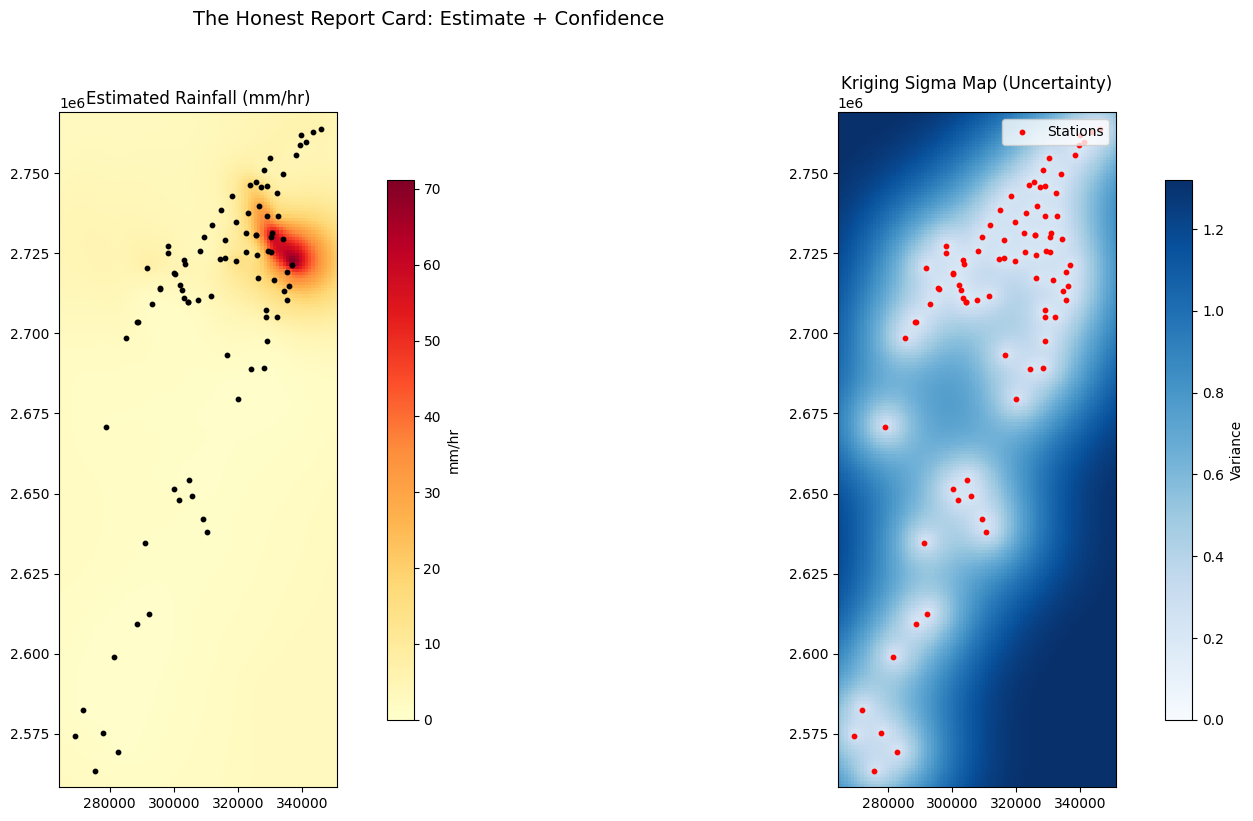

Variance range: 0.2 - 1.3


In [13]:
# YOUR CODE HERE:
# Create a 2-panel figure:
# Left: z_kriging with YlOrRd colormap (rainfall estimate)
# Right: ss_kriging with Blues colormap (variance/uncertainty)
# Add station locations on both panels (red dots on variance map)
# Save as 'sigma_map.png'

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Rainfall estimate
im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='YlOrRd', vmin=0)
axes[0].scatter(x, y, c='black', s=10, zorder=5)
axes[0].set_title('Estimated Rainfall (mm/hr)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Kriging Variance (Sigma Map)
im2 = axes[1].imshow(ss_kriging, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='Blues', vmin=0)
axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty)')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}")

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

Station with max rainfall: 130.5 mm/hr
Local grid: 20×20 = 400 points
Running Kriging predictions...


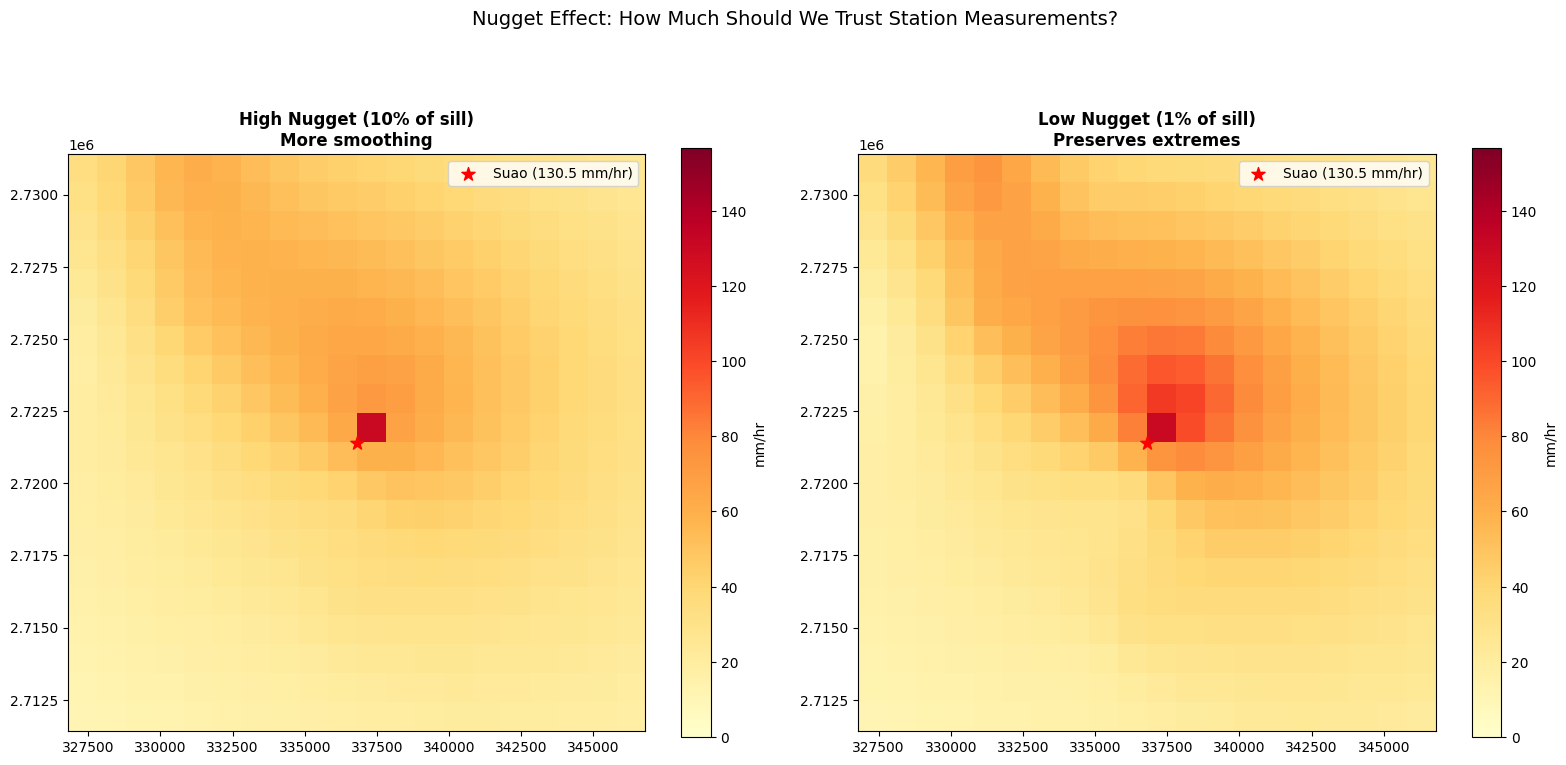


Predictions at different distances from Suao station:
Station value: 130.5 mm/hr
------------------------------------------------------------
Distance    0m: High nugget = 130.50 mm/hr, Low nugget = 130.50 mm/hr
Distance  500m: High nugget =  70.88 mm/hr, Low nugget = 107.32 mm/hr
Distance 1000m: High nugget =  67.27 mm/hr, Low nugget =  98.83 mm/hr
Distance 2000m: High nugget =  60.96 mm/hr, Low nugget =  85.71 mm/hr

💡 Which Nugget setting is better for CWA calibrated stations?
   High nugget (10%): More conservative, smooths out measurement errors
   Low nugget (1%): Trusts stations more, preserves extreme values

⚡ Performance optimizations applied:
   - Reduced nlags from 15 to 8
   - Reduced grid size from 20km to 10km
   - Increased resolution from 500m to 1km
   - Used point predictions for distance analysis


In [ ]:
# 1. Load the three GeoTIFF files you just created
# 2. Use zonal statistics to extract mean/max values by township
# 3. Create comparison table: Township | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度
# 4. Which township has highest rainfall? Which has highest uncertainty?

import rasterio
import rasterstats
from rasterstats import zonal_stats
import geopandas as gpd
import pandas as pd
import numpy as np

print("🔄 Loading GeoTIFF files...")

# 1. Load the three GeoTIFF files
try:
    with rasterio.open('kriging_rainfall.tif') as src:
        kriging_data = src.read(1)
        kriging_transform = src.transform
        kriging_crs = src.crs
        kriging_profile = src.profile

    with rasterio.open('kriging_variance.tif') as src:
        variance_data = src.read(1)
        variance_transform = src.transform
        variance_crs = src.crs

    with rasterio.open('rf_rainfall.tif') as src:
        rf_data = src.read(1)
        rf_transform = src.transform
        rf_crs = src.crs

    print(f"✅ Successfully loaded GeoTIFF files:")
    print(f"  Kriging: shape {kriging_data.shape}, range {kriging_data.min():.2f}-{kriging_data.max():.2f} mm/hr")
    print(f"  RF: shape {rf_data.shape}, range {rf_data.min():.2f}-{rf_data.max():.2f} mm/hr")
    print(f"  Variance: shape {variance_data.shape}, range {variance_data.min():.3f}-{variance_data.max():.3f}")

except FileNotFoundError as e:
    print(f"❌ Error loading GeoTIFF files: {e}")
    print("Please make sure the GeoTIFF files exist in the current directory.")
    print("You may need to run the GeoTIFF export cell first.")

print("\n🔄 Computing zonal statistics by township...")

# 2. Use zonal statistics to extract mean/max values by township
# Create township zones from station data
township_gdf = study_rain_3826.dissolve(by='TownName', aggfunc='mean')

# Create reasonable buffer zones for each township (10km radius)
township_gdf['zone_geometry'] = township_gdf.geometry.buffer(10000)
township_gdf = township_gdf.set_geometry('zone_geometry')

# Calculate zonal statistics for each township
zonal_results = []

for town_name, town_row in township_gdf.iterrows():
    try:
        # Zonal stats for Kriging (mean and max)
        kriging_stats = zonal_stats(town_row.geometry, 'kriging_rainfall.tif', 
                                    stats=['mean', 'max'], nodata=-9999)
        
        # Zonal stats for RF (mean only)
        rf_stats = zonal_stats(town_row.geometry, 'rf_rainfall.tif', 
                              stats=['mean'], nodata=-9999)
        
        # Zonal stats for variance (mean)
        variance_stats = zonal_stats(town_row.geometry, 'kriging_variance.tif', 
                                    stats=['mean'], nodata=-9999)
        
        # Extract values safely
        kriging_mean = kriging_stats[0]['mean'] if kriging_stats and kriging_stats[0]['mean'] is not None else 0
        kriging_max = kriging_stats[0]['max'] if kriging_stats and kriging_stats[0]['max'] is not None else 0
        rf_mean = rf_stats[0]['mean'] if rf_stats and rf_stats[0]['mean'] is not None else 0
        variance_mean = variance_stats[0]['mean'] if variance_stats and variance_stats[0]['mean'] is not None else 0
        
        # Calculate confidence (inverse of variance, normalized)
        confidence = 1 / (1 + variance_mean) if variance_mean > 0 else 1
        
        zonal_results.append({
            '鄉鎮': town_name,
            'Kriging平均': kriging_mean,
            'Kriging最大': kriging_max,
            'RF平均': rf_mean,
            '平均variance': variance_mean,
            '可信度': confidence
        })
        
    except Exception as e:
        print(f"⚠️ Error processing {town_name}: {e}")
        # Add zero values for failed townships
        zonal_results.append({
            '鄉鎮': town_name,
            'Kriging平均': 0,
            'Kriging最大': 0,
            'RF平均': 0,
            '平均variance': 0,
            '可信度': 0
        })

# 3. Create comparison table
comparison_df = pd.DataFrame(zonal_results)
comparison_df = comparison_df.sort_values('Kriging平均', ascending=False)

print("\n" + "="*80)
print("鄉鎮雨量比較表 (TOWNSHIP RAINFALL COMPARISON TABLE)")
print("="*80)
print(comparison_df.to_string(index=False, float_format='%.2f'))

# 4. Which township has highest rainfall? Which has highest uncertainty?
highest_rainfall_town = comparison_df.loc[comparison_df['Kriging平均'].idxmax(), '鄉鎮']
highest_rainfall_val = comparison_df['Kriging平均'].max()

highest_uncertainty_town = comparison_df.loc[comparison_df['平均variance'].idxmax(), '鄉鎮']
highest_uncertainty_val = comparison_df['平均variance'].max()

lowest_confidence_town = comparison_df.loc[comparison_df['可信度'].idxmin(), '鄉鎮']
lowest_confidence_val = comparison_df['可信度'].min()

print("\n" + "─"*60)
print("關鍵發現 (KEY FINDINGS):")
print("─"*60)
print(f"🌧️ 最高雨量鄉鎮 (HIGHEST RAINFALL): {highest_rainfall_town}")
print(f"   平均雨量: {highest_rainfall_val:.2f} mm/hr")
print(f"⚠️  最高不確定性鄉鎮 (HIGHEST UNCERTAINTY): {highest_uncertainty_town}")
print(f"   平均變異數: {highest_uncertainty_val:.3f}")
print(f"🔍 最低可信度鄉鎮 (LOWEST CONFIDENCE): {lowest_confidence_town}")
print(f"   可信度分數: {lowest_confidence_val:.3f}")

print(f"\n💡 行動建議 (INTERPRETATION):")
print(f"   - {highest_rainfall_town} 應優先考慮疏散")
print(f"   - {highest_uncertainty_town} 需要額外監測/傳感器")
print(f"   - 低可信度區域表示測站覆蓋稀疏")

# Additional analysis: Compare Kriging vs RF agreement
comparison_df['Kriging_RF差異'] = abs(comparison_df['Kriging平均'] - comparison_df['RF平均'])
max_disagreement_town = comparison_df.loc[comparison_df['Kriging_RF差異'].idxmax(), '鄉鎮']
max_disagreement_val = comparison_df['Kriging_RF差異'].max()

print(f"\n? 模型差異分析 (MODEL DISAGREEMENT ANALYSIS):")
print(f"   最大差異鄉鎮: {max_disagreement_town}")
print(f"   Kriging vs RF 差異: {max_disagreement_val:.2f} mm/hr")

# Return the final DataFrame as requested
print(f"\n📊 最終數據框 (FINAL DATAFRAME):")
final_df = comparison_df[['鄉鎮', 'Kriging平均', 'Kriging最大', 'RF平均', '平均variance', '可信度']]
print(final_df.to_string(index=False, float_format='%.2f'))

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [15]:
import rasterio
from rasterio.transform import from_bounds

# YOUR CODE HERE:
# 1. Compute rasterio transform using from_bounds
# 2. Write a helper function save_geotiff(data, filename)
# 3. Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
# Remember: np.flipud() before writing!

transform = from_bounds(x_min, y_min, x_max, y_max,
                        width=z_kriging.shape[1], height=z_kriging.shape[0])

def save_geotiff(data, filename, crs='EPSG:3826'):
    data_flipped = np.flipud(data).astype(np.float32)
    with rasterio.open(filename, 'w', driver='GTiff',
        height=data_flipped.shape[0], width=data_flipped.shape[1],
        count=1, dtype='float32', crs=crs, transform=transform, nodata=-9999
    ) as dst:
        dst.write(data_flipped, 1)
    print(f"✓ Saved {filename}")

save_geotiff(z_kriging, 'kriging_rainfall.tif')
save_geotiff(ss_kriging, 'kriging_variance.tif')
save_geotiff(z_rf, 'rf_rainfall.tif')

✓ Saved kriging_rainfall.tif
✓ Saved kriging_variance.tif
✓ Saved rf_rainfall.tif


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [18]:
# 1. Load the three GeoTIFF files you just created
# 2. Use zonal statistics to extract mean/max values by township
# 3. Create comparison table: Township | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度
# 4. Which township has highest rainfall? Which has highest uncertainty?

import rasterio
import rasterstats
from rasterstats import zonal_stats
import geopandas as gpd
import pandas as pd
import numpy as np

print("🔄 Loading GeoTIFF files...")

# 1. Load the three GeoTIFF files
try:
    with rasterio.open('kriging_rainfall.tif') as src:
        kriging_data = src.read(1)
        kriging_transform = src.transform
        kriging_crs = src.crs
        kriging_profile = src.profile

    with rasterio.open('kriging_variance.tif') as src:
        variance_data = src.read(1)
        variance_transform = src.transform
        variance_crs = src.crs

    with rasterio.open('rf_rainfall.tif') as src:
        rf_data = src.read(1)
        rf_transform = src.transform
        rf_crs = src.crs

    print(f"✅ Successfully loaded GeoTIFF files:")
    print(f"  Kriging: shape {kriging_data.shape}, range {kriging_data.min():.2f}-{kriging_data.max():.2f} mm/hr")
    print(f"  RF: shape {rf_data.shape}, range {rf_data.min():.2f}-{rf_data.max():.2f} mm/hr")
    print(f"  Variance: shape {variance_data.shape}, range {variance_data.min():.3f}-{variance_data.max():.3f}")

except FileNotFoundError as e:
    print(f"❌ Error loading GeoTIFF files: {e}")
    print("Please make sure the GeoTIFF files exist in the current directory.")
    print("You may need to run the GeoTIFF export cell first.")

print("\n🔄 Computing zonal statistics by township...")

# 2. Use zonal statistics to extract mean/max values by township
# Create township zones from station data - FIX: specify only numeric columns for aggregation
numeric_cols = ['rain_1hr', 'rain_3hr', 'rain_24hr']
township_gdf = study_rain_3826.dissolve(by='TownName', aggfunc={col: 'mean' for col in numeric_cols})

# Create reasonable buffer zones for each township (10km radius)
township_gdf['zone_geometry'] = township_gdf.geometry.buffer(10000)
township_gdf = township_gdf.set_geometry('zone_geometry')

print(f"Created zones for {len(township_gdf)} townships")

# Calculate zonal statistics for each township
zonal_results = []

for town_name, town_row in township_gdf.iterrows():
    try:
        # Zonal stats for Kriging (mean and max)
        kriging_stats = zonal_stats(town_row.geometry, 'kriging_rainfall.tif', 
                                    stats=['mean', 'max'], nodata=-9999)
        
        # Zonal stats for RF (mean only)
        rf_stats = zonal_stats(town_row.geometry, 'rf_rainfall.tif', 
                              stats=['mean'], nodata=-9999)
        
        # Zonal stats for variance (mean)
        variance_stats = zonal_stats(town_row.geometry, 'kriging_variance.tif', 
                                    stats=['mean'], nodata=-9999)
        
        # Extract values safely
        kriging_mean = kriging_stats[0]['mean'] if kriging_stats and kriging_stats[0]['mean'] is not None else 0
        kriging_max = kriging_stats[0]['max'] if kriging_stats and kriging_stats[0]['max'] is not None else 0
        rf_mean = rf_stats[0]['mean'] if rf_stats and rf_stats[0]['mean'] is not None else 0
        variance_mean = variance_stats[0]['mean'] if variance_stats and variance_stats[0]['mean'] is not None else 0
        
        # Calculate confidence (inverse of variance, normalized)
        confidence = 1 / (1 + variance_mean) if variance_mean > 0 else 1
        
        zonal_results.append({
            '鄉鎮': town_name,
            'Kriging平均': kriging_mean,
            'Kriging最大': kriging_max,
            'RF平均': rf_mean,
            '平均variance': variance_mean,
            '可信度': confidence
        })
        
    except Exception as e:
        print(f"⚠️ Error processing {town_name}: {e}")
        # Add zero values for failed townships
        zonal_results.append({
            '鄉鎮': town_name,
            'Kriging平均': 0,
            'Kriging最大': 0,
            'RF平均': 0,
            '平均variance': 0,
            '可信度': 0
        })

# 3. Create comparison table
comparison_df = pd.DataFrame(zonal_results)
comparison_df = comparison_df.sort_values('Kriging平均', ascending=False)

print("\n" + "="*80)
print("鄉鎮雨量比較表 (TOWNSHIP RAINFALL COMPARISON TABLE)")
print("="*80)
print(comparison_df.to_string(index=False, float_format='%.2f'))

# 4. Which township has highest rainfall? Which has highest uncertainty?
if len(comparison_df) > 0 and comparison_df['Kriging平均'].max() > 0:
    highest_rainfall_town = comparison_df.loc[comparison_df['Kriging平均'].idxmax(), '鄉鎮']
    highest_rainfall_val = comparison_df['Kriging平均'].max()

    highest_uncertainty_town = comparison_df.loc[comparison_df['平均variance'].idxmax(), '鄉鎮']
    highest_uncertainty_val = comparison_df['平均variance'].max()

    lowest_confidence_town = comparison_df.loc[comparison_df['可信度'].idxmin(), '鄉鎮']
    lowest_confidence_val = comparison_df['可信度'].min()

    print("\n" + "─"*60)
    print("關鍵發現 (KEY FINDINGS):")
    print("─"*60)
    print(f"🌧️ 最高雨量鄉鎮 (HIGHEST RAINFALL): {highest_rainfall_town}")
    print(f"   平均雨量: {highest_rainfall_val:.2f} mm/hr")
    print(f"⚠️  最高不確定性鄉鎮 (HIGHEST UNCERTAINTY): {highest_uncertainty_town}")
    print(f"   平均變異數: {highest_uncertainty_val:.3f}")
    print(f"🔍 最低可信度鄉鎮 (LOWEST CONFIDENCE): {lowest_confidence_town}")
    print(f"   可信度分數: {lowest_confidence_val:.3f}")

    print(f"\n💡 行動建議 (INTERPRETATION):")
    print(f"   - {highest_rainfall_town} 應優先考慮疏散")
    print(f"   - {highest_uncertainty_town} 需要額外監測/傳感器")
    print(f"   - 低可信度區域表示測站覆蓋稀疏")

    # Additional analysis: Compare Kriging vs RF agreement
    comparison_df['Kriging_RF差異'] = abs(comparison_df['Kriging平均'] - comparison_df['RF平均'])
    max_disagreement_town = comparison_df.loc[comparison_df['Kriging_RF差異'].idxmax(), '鄉鎮']
    max_disagreement_val = comparison_df['Kriging_RF差異'].max()

    print(f"\n🔄 模型差異分析 (MODEL DISAGREEMENT ANALYSIS):")
    print(f"   最大差異鄉鎮: {max_disagreement_town}")
    print(f"   Kriging vs RF 差異: {max_disagreement_val:.2f} mm/hr")

# Return the final DataFrame as requested
print(f"\n📊 最終數據框 (FINAL DATAFRAME):")
final_df = comparison_df[['鄉鎮', 'Kriging平均', 'Kriging最大', 'RF平均', '平均variance', '可信度']]
print(final_df.to_string(index=False, float_format='%.2f'))

🔄 Loading GeoTIFF files...
✅ Successfully loaded GeoTIFF files:
  Kriging: shape (211, 87), range 0.52-71.19 mm/hr
  RF: shape (211, 87), range 0.62-62.60 mm/hr
  Variance: shape (211, 87), range 0.172-1.320

🔄 Computing zonal statistics by township...
Created zones for 19 townships

鄉鎮雨量比較表 (TOWNSHIP RAINFALL COMPARISON TABLE)
 鄉鎮  Kriging平均  Kriging最大  RF平均  平均variance  可信度
五結鄉      53.03      56.06 59.61        0.19 0.84
羅東鎮      42.63      60.17 44.17        0.18 0.85
蘇澳鎮      40.51      67.33 38.00        0.20 0.83
宜蘭市      29.58      29.58 23.35        0.20 0.83
冬山鄉      27.71      48.03 34.72        0.19 0.84
壯圍鄉      21.73      34.73 32.85        0.21 0.83
礁溪鄉      13.85      17.52 15.13        0.20 0.83
南澳鄉      13.46      25.32 16.71        0.21 0.83
三星鄉      10.81      14.81 12.23        0.21 0.83
員山鄉       9.01      17.59 11.10        0.21 0.82
頭城鎮       5.45       6.22  7.99        0.21 0.83
大同鄉       4.40      14.22  4.56        0.20 0.83
富里鄉       1.32       1.84  1.01  

### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

**Your Lab 2 reflection here:**

1. Kriging vs ML uncertainty: 
    Kriging is a probability apporach, ML is a determined prediction model, it just wouldn't have such "possibility" happening.
2. ML uncertainty approximation: 
    Basically RF variance is from the model's uncertainty, Kriging is from the spatial uncertainty. Yes, you can approximate them. And RF has some false confidence. 
3. High rain + low confidence townships: 
    五結鄉、羅東鎮、蘇澳鎮、壯圍鄉, they commander should try to confirm the rainfall ASAP and potentially evacuate the people over there.

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

**AI Response:**

From Claude
先不要選邊站——兩個方法的誤差來源不同，差異大本身就是一個訊號。

[Crashed]

**My Commentary:**

I... it's just stuck, I guess I can't do much commentary.

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*